# Self-reported expressibility predicts communicative success: Open dataset, validation, and simulation
## Simulating experiments based on posterior estimates of expressibility

Author: Aleksandra Ćwiek, Susanne Fuchs, Wim Pouw, and Šárka Kadavá<br>
Date: 1. 6. 2025

In this script, we simulate experiments in which vocal and gesture expressibility is compared. The simulations vary in the following aspects:
- the number of participants (10. 15, 20)
- the number of concepts (12, 18, 24)
- category from which concepts are sampled (unconstrained, from action-emotion-object, from noun-adjective-verb, from three random categories)

## Basic settings

We first load in the Dutch data estimated from the Bayesian modeling, and merge the data with information from the basic concept list (e.g., semantic category, PoS, etc.)

In [1]:
# Load packages
import os
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Prepare data
curfolder = os.getcwd()
parentfolder = os.path.abspath(os.path.join(curfolder, os.pardir))
mainfolder = os.path.abspath(os.path.join(parentfolder, os.pardir))

# print(parentfolder)
# print(mainfolder)

expressfolder = os.path.join(mainfolder, '01_Expressibility\\data\\')
datafolder = os.path.join(parentfolder, 'datasets')
plotfolder = os.path.join(parentfolder, 'plots')

# print(datafolder)

# Load data
express = pd.read_csv(os.path.join(expressfolder, 'df_estim_dutch.csv')) 
concepts = pd.read_excel(os.path.join(expressfolder, 'concept_list_info.xlsx'))

# Rename column German to word
concepts = concepts.rename(columns={'Dutch': 'word'})

# Columns PoS and SemanticCat from concepts to df
df = pd.merge(express, concepts[['word', 'PoS', 'SemanticCat']], on='word')

# Get rid of multimodal data
df = df[df['modality'] != 'multimodal']
df = df.drop_duplicates(subset=['word', 'modality'], keep='first')

# rename value 'locomotion' in SemanticCat to 'motion'
df.loc[df['SemanticCat'] == 'locomotion', 'SemanticCat'] = 'motion'

# delete following columns
df = df.drop(columns=['n', 'diff_expr', 'diff_rank', 'SemanticSubcat'])

# get rid of the first, unnamed column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head(15)


,word,modality,fit,se,lwr,upr,avg_expressibility_norm,German,English,PoS,SemanticCat
0,aanraken,gesture,0.671534,0.039510,0.588136,0.744594,0.680309,Berührung,touch,noun,sensory
2,aanraken,vocal,0.206290,0.038294,0.142399,0.294340,0.177373,Berührung,touch,noun,sensory
3,aarde,gesture,0.540447,0.049120,0.444047,0.632926,0.543955,Erde,soil,noun,environment
5,aarde,vocal,0.195378,0.038231,0.132023,0.281966,0.170487,Erde,soil,noun,environment
6,ademen,gesture,0.780851,0.031091,0.712689,0.835971,0.765703,atmen,to breathe,verb,sensory
8,ademen,vocal,0.785386,0.034437,0.706235,0.845971,0.818681,atmen,to breathe,verb,sensory
9,alles,gesture,0.351968,0.042526,0.272118,0.437654,0.360793,alles,all,pronoun,abstract
11,alles,vocal,0.117634,0.026610,0.074905,0.183275,0.080647,alles,all,pronoun,abstract
12,arm (lichaam),gesture,0.536086,0.042306,0.452815,0.618628,0.526008,Arm,arm,noun,body
14,arm (lichaam),vocal,0.127700,0.026660,0.083494,0.191696,0.079813,Arm,arm,noun,body


## Data check, descriptives and plots

Let's check how the data looks like

c:\Users\kadava\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\kadava\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\kadava\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\kadava\AppData\Local\anaconda3\Lib\site-packages\seabo

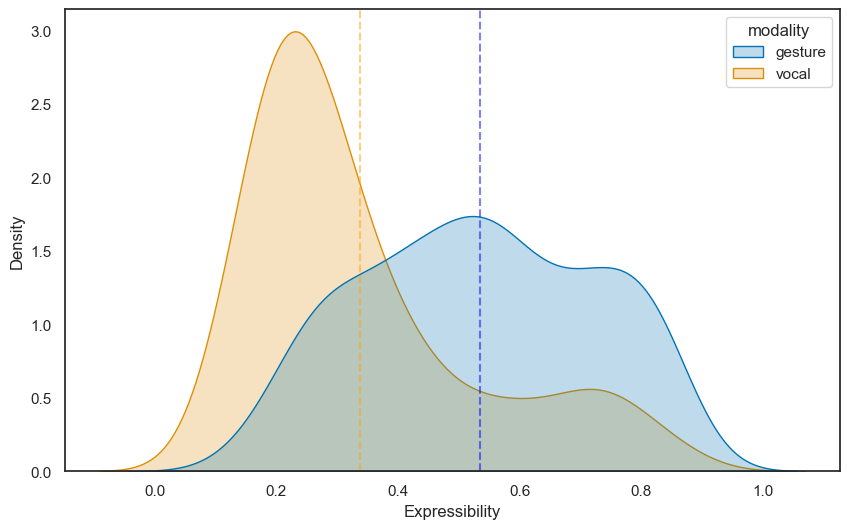

In [2]:
# Create a density plot

sns.set_theme(style="white", palette="colorblind", font='Arial', font_scale=1)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='fit', hue='modality', fill=True, common_norm=False)
plt.xlabel('Expressibility')
plt.ylabel('Density')

# Dashed line for mean
plt.axvline(x=df[df['modality'] == 'vocal']['fit'].mean(), color='orange', linestyle='--', alpha=0.5)
plt.axvline(x=df[df['modality'] == 'gesture']['fit'].mean(), color='blue', linestyle='--', alpha=0.5)

plt.show()


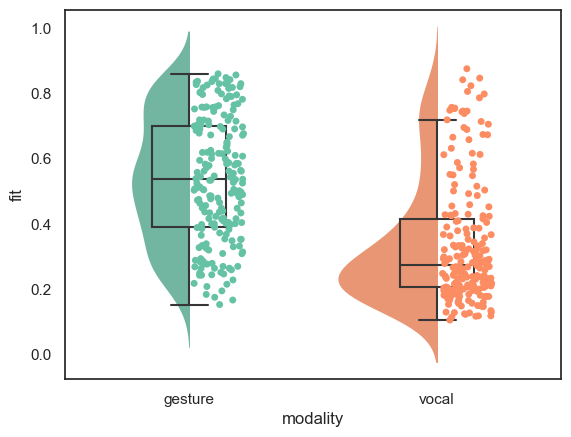

In [3]:
from warnings import filterwarnings
filterwarnings("ignore", category=FutureWarning)

# Density plot with boxplot
sns.set_style('white')
palette = 'Set2'
ax = sns.violinplot(x="modality", y="fit", data=df, dodge=False,
                    palette=palette,
                    density_norm='width', inner=None, edgecolor=None, linewidth=0)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

sns.boxplot(x="modality", y="fit", data=df, saturation=1, showfliers=False,
            width=0.3, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)
old_len_collections = len(ax.collections)
sns.stripplot(x="modality", y="fit", data=df, palette=palette, dodge=False, ax=ax)
for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))
ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.show()

So gesture expressibility is slightly better, but we have some overlap, and vocal expressibility has quite a long (positive) tail

In [4]:
# Some descriptive statistics

## Mean
df.groupby('modality')['fit'].mean() 

## Standard deviation
df.groupby('modality')['fit'].std()

## Median
df.groupby('modality')['fit'].median()

# Table with all the statistics
print(df.groupby('modality')['fit'].agg(['mean', 'std', 'median']))


              mean       std    median
modality                              
gesture   0.534585  0.190032  0.535546
vocal     0.337105  0.188274  0.273251


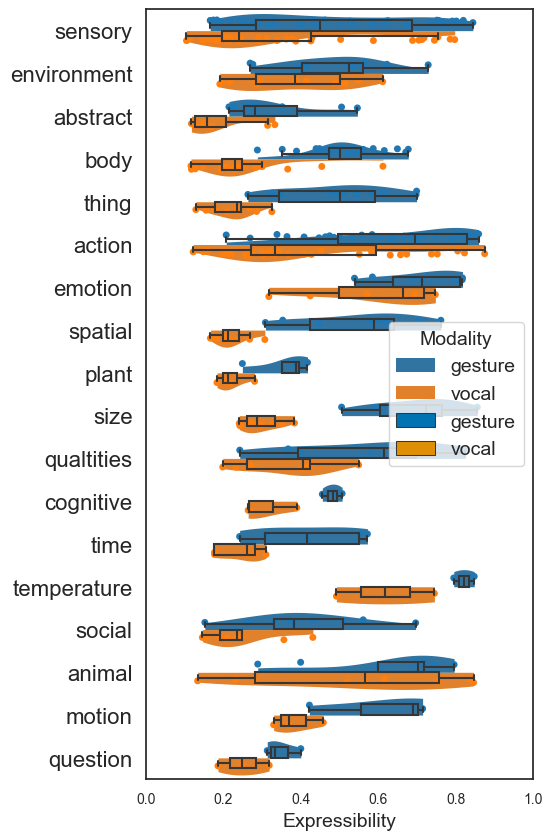

In [5]:
from warnings import filterwarnings
filterwarnings("ignore", category=FutureWarning)

# Gesture and vocal modality stratified by semantic category
plt.rcParams['font.family'] = 'Times New Roman'

sns.set_style('white')
plt.figure(figsize=(5, 10))  
palette = sns.color_palette("tab10", 2)

ax = sns.violinplot(y="SemanticCat", x="fit", hue="modality", data=df, dodge=True,
                    palette=palette, split=True, inner=None, edgecolor=None, linewidth=0, legend=False, scale='width', alpha=0.9, cut=0)

for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width, height, transform=ax.transData))

sns.boxplot(y="SemanticCat", x="fit", hue="modality", data=df, saturation=1, showfliers=False,
            width=0.5, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)

old_len_collections = len(ax.collections)
sns.stripplot(y="SemanticCat", x="fit", hue="modality", data=df, palette=palette, dodge=True, ax=ax, legend=False, zorder=1)

for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0, 0]))

plt.legend(title='Modality', title_fontsize='14', fontsize='14')
plt.xticks(rotation=0)  # Rotate x-axis labels
plt.xticks(fontsize=10)  
plt.yticks(fontsize=16)  
plt.xlabel('Expressibility', fontsize=14)  
plt.ylabel('')  
plt.xlim(0, 1)  
plt.show()


Most of the categories seem to have different distributions but in general they kind of overlap - see, e.g., sensory, environment. That has few exceptions such as motion, or cognitive concepts.

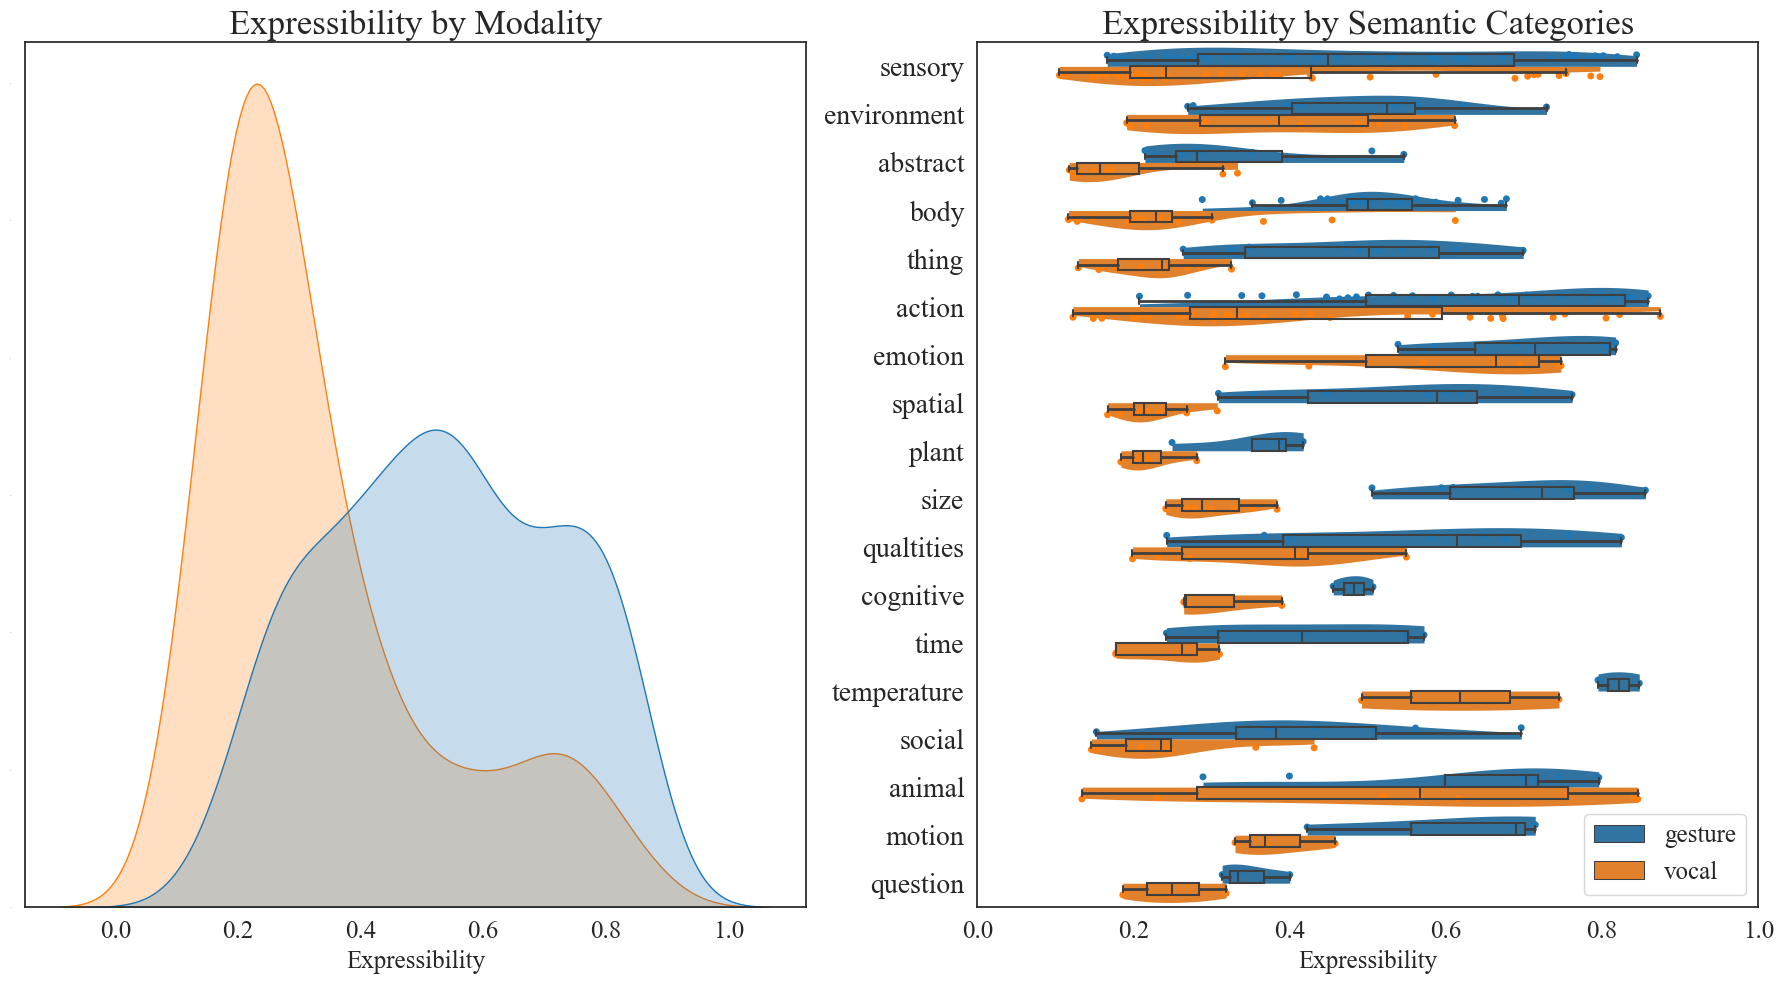

In [6]:
from warnings import filterwarnings
filterwarnings("ignore", category=FutureWarning)

# Set overall aesthetics
sns.set_theme(style="white", palette="colorblind", font='Arial', font_scale=1)
plt.rcParams['font.family'] = 'Times New Roman'

# === Plot 2: Violin + Box + Strip Plot ===
palette = sns.color_palette("tab10", 2)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 10))  # 1 row, 2 columns

# === Plot 1: KDE Plot ===
sns.kdeplot(data=df, x='fit', hue='modality', fill=True, common_norm=False, ax=axes[0], palette=palette, legend=False)
axes[0].set_xlabel('Expressibility', fontsize=18)
axes[0].set_ylabel('')
axes[0].set_title("Expressibility by Modality", fontsize=25)
axes[0].tick_params(axis='x', labelrotation=0, labelsize=18)
axes[0].tick_params(axis='y', labelsize=0)

# Violin plot
sns.violinplot(y="SemanticCat", x="fit", hue="modality", data=df, dodge=True,
               palette=palette, split=True, inner=None, scale='width',
               linewidth=0, cut=0, ax=axes[1], alpha=0.9)

# Boxplot on top (IMPORTANT: use same dodge=True and same hue order)
sns.boxplot(y="SemanticCat", x="fit", hue="modality", data=df, dodge=True,
            width=0.5, palette=palette, showcaps=True, boxprops={'facecolor': 'none', 'zorder': 3},
            showfliers=False, whiskerprops={'linewidth': 2}, ax=axes[1])

# Stripplot overlay
sns.stripplot(y="SemanticCat", x="fit", hue="modality", data=df,
              dodge=True, palette=palette, ax=axes[1], legend=False, zorder=1)

# Cleanup duplicate legends (from three hue layers)
handles, labels = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1].legend(by_label.values(), by_label.keys(), title='', title_fontsize=14, fontsize=18)

# Aesthetics
axes[1].tick_params(axis='x', labelrotation=0, labelsize=18)
axes[1].tick_params(axis='y', labelsize=20)
axes[1].set_xlabel('Expressibility', fontsize=18)
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1)
axes[1].set_title("Expressibility by Semantic Categories", fontsize=25)


# Tight layout
plt.tight_layout()
plt.show()


## Simulations

* simulation 1 = random concepts without domain constrain

number of concepts 24 - 18 - 12 
number of 'participants': 20 - 15 - 10

* simulation  2 = random concepts from A-E-O semantic categories 

number of concepts 24 - 18 - 12 
number of 'participants': 20 - 15 - 10

* simulation 3 = random concepts from three random semantic categories

number of concepts 24 - 18 - 12 
number of 'participants': 20 - 15 - 10

* simulation 4 = random concepts from N-V-A (PoS)

number of concepts 24 - 18 - 12  
number of 'participants': 20 - 15 - 10

* simulation 5 (sanity check) = random concepts from vocal-favoring category

number of concepts 24 - 18 - 12
number of 'participants': 20 - 15 - 10

### Function to simulate experiments

In [6]:
def simulate_experiment(domain, categories, num_sim, num_words, num_data, concepts, distribution_matrix, num_cat=3):
    # Domain is the variable from which you want to draw category (e.g., PoS, semantic category)
    # Categories is a list of categories
    # Num_cat is number of categories, 3 default
    # Num_sim is number of simulations
    # Num_words is number of concepts per category
    # Concepts is the concepts df
    # Distribution_matrix is the matrix of distribution (e.g., posterior predictive distribution)

    # If domain and categories are None, just sample the num_words without domain constrain  
    if domain is None and categories is None:
        # Make a list of unique words
        unique_words = concepts['word'].unique()
        # Create as many empty lists as there is simulations
        samples = [[] for _ in range(num_sim)]
        # For each of the lists, append x random words 
        for i in range(num_sim):
            samples[i].append(random.sample(list(unique_words), num_words))
        # Concatenate the lists
        samples = [x for y in samples for x in y]

    # If domain is random, sample the num_words from random categories
    elif domain is not None and categories == 'random':
        samples = []
        # Create a list of SemanticCat from concepts_df
        cats = concepts[domain].unique()
        min_occurence = num_words * 2 # 2 modalities

        # Which categories have less than min_occurence words?
        to_delete = []
        for i in cats:
            if len(concepts[concepts[domain] == i]) < min_occurence: 
                # print(i)
                # Append to list to delete
                to_delete.append(i)
        # Make a new df without the categories in to_delete
        concepts_temp = concepts[~concepts[domain].isin(to_delete)]
        for i in range(num_sim):
            # Pick three random values of SemanticCat
            cat = random.sample(list(concepts_temp[domain].unique()), num_cat)
            # print(cat)
            # Make lists of unique words from these categories
            words_cat1 = concepts_temp[concepts_temp[domain] == cat[0]]['word'].unique()
            words_cat2 = concepts_temp[concepts_temp[domain] == cat[1]]['word'].unique()
            words_cat3 = concepts_temp[concepts_temp[domain] == cat[2]]['word'].unique()
            
            # Select 6 words from each cat
            sample_cat1 = random.sample(list(words_cat1), num_words)
            sample_cat2 = random.sample(list(words_cat2), num_words)
            sample_cat3 = random.sample(list(words_cat3), num_words)

            # Concatenate the lists
            samples_category = [sample_cat1, sample_cat2, sample_cat3]
            # Concatenate the three lists inside the list into one list
            samples_category = [x for y in samples_category for x in y]
            # Append to categ_random
            samples.append(samples_category)
    
    # Otherwise, sample the num_words from the categories
    else:
        # For each category defined, make a list of the unique words
        unique_words = []
        for i in range(len(categories)):
            unique_words.append(concepts[concepts[domain] == categories[i]]['word'].unique())

        # Create as many empty lists as there are categories
        samples = [[] for _ in range(len(categories))]

        # For each of the lists, append x random words from the corresponding category
        for i in range(len(categories)):
            for _ in range(num_sim):
                samples[i].append(random.sample(list(unique_words[i]), num_words))

        # Bind the lists together 
        samples = list(zip(samples[0], samples[1], samples[2]))
        # Concatenate the lists
        samples = [[x for y in z for x in y] for z in samples]
        
    # Initiate empty list where we store all the experiments
    expressibility = []

    # Loop over each sample
    for sample in samples:

        # Initiate empty lists for each modality
        expr_voc_list = []
        expr_ges_list = []
    
        # For each concept in a sample, search for the corresponding indices for gesture and vocal modalities
        for concept in sample:
            # Search for the index of the concept in interest
            index_voc = concepts.loc[(concepts['word'] == concept) & (concepts['modality'] == 'vocal'), 'index'].values[0]
            index_ges = concepts.loc[(concepts['word'] == concept) & (concepts['modality'] == 'gesture'), 'index'].values[0]
            # For each value in ind_voc and ind_ges, pick x values from the ppd matrix from the corresponding column   
            expr_voc = np.random.choice(distribution_matrix[index_voc], num_data).tolist()
            expr_ges = np.random.choice(distribution_matrix[index_ges], num_data).tolist()
            # Append the values to the modality list for this sample
            expr_voc_list.append(expr_voc)
            expr_ges_list.append(expr_ges)
    
        # Combine exprs_voc and exprs_ges for each sample and add to expressibility
        combined_exprs = list(zip(sample, expr_voc_list, expr_ges_list))
        expressibility.append(combined_exprs)

    
    return expressibility


In [13]:
from warnings import filterwarnings
filterwarnings("ignore", category=FutureWarning)

# Here we will store the results
simfolder = os.path.join(datafolder, 'simulation_results')

# Load in the ppd matrix
ppd = pd.read_csv(os.path.join(datafolder, 'ppd_matrix.csv'))
concepts = pd.read_csv(os.path.join(datafolder, 'empty_df.csv'))

# Create to concepts a column index
concepts['index'] = None

# Fill it will values from V1 to V414 so that we can access the ppd matrix
for i in range(1, 415):
    concepts['index'][i-1] = 'V' + str(i)

# Add relevant information
concepts_df = pd.merge(concepts, df[['word','SemanticCat', 'PoS']], on='word')

# Delete duplicate rows
concepts_df = concepts_df.drop_duplicates(subset=['word', 'modality'], keep='first')

concepts_df.head(10)

,word,modality,index,SemanticCat,PoS
0,aanraken,gesture,V1,sensory,noun
2,aarde,gesture,V2,environment,noun
4,ademen,gesture,V3,sensory,verb
6,alles,gesture,V4,abstract,pronoun
8,arm (lichaam),gesture,V5,body,noun
10,as,gesture,V6,thing,noun
12,badderen,gesture,V7,action,verb
14,bang,gesture,V8,emotion,adjective
16,been,gesture,V9,body,noun
18,beneden,gesture,V10,spatial,adverb


### SIM 1

In [ ]:
# SIM1
# 18 concepts, 20 data points

# Set seed
random.seed(234)

exp_18_20 = simulate_experiment(None, None, 100000, 18, 20, concepts_df, ppd)

# Wrap as an object array
exp_18_20_obj = np.array(exp_18_20, dtype=object)

# Save it
np.save(os.path.join(simfolder, 'exp_18_20.npy'), exp_18_20_obj, allow_pickle=True)


In [ ]:
# SIM1
# 18 concepts, 15 data points

# Set seed
random.seed(345)

exp_18_15 = simulate_experiment(None, None, 100000, 18, 15, concepts_df, ppd)

# Wrap as an object array
exp_18_15_obj = np.array(exp_18_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_18_15.npy'), exp_18_15_obj, allow_pickle=True)


In [ ]:
# SIM1
# 18 concepts, 10 data points

# Set seed
random.seed(456)

exp_18_10 = simulate_experiment(None, None, 100000, 18, 10, concepts_df, ppd)

# Wrap as an object array
exp_18_10_obj = np.array(exp_18_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_18_10.npy'), exp_18_10_obj, 'dtype=object')


In [ ]:
# SIM1
# 24 concepts, 20 data points

# Set seed
random.seed(2420)

exp_24_20 = simulate_experiment(None, None, 100000, 24, 20, concepts_df, ppd)

# Wrap as an object array
exp_24_20_obj = np.array(exp_24_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_24_20.npy'), exp_24_20_obj, allow_pickle=True)

In [ ]:
# SIM1
# 24 concepts, 15 data points

# Set seed
random.seed(2415)

exp_24_15 = simulate_experiment(None, None, 100000, 24, 15, concepts_df, ppd)

# Wrap as an object array
exp_24_15_obj = np.array(exp_24_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_24_15.npy'), exp_24_15_obj, allow_pickle=True)


In [ ]:
# SIM1
# 24 concepts, 10 data points

# Set seed
random.seed(2410)

exp_24_10 = simulate_experiment(None, None, 100000, 24, 10, concepts_df, ppd)

# Wrap as an object array
exp_24_10_obj = np.array(exp_24_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_24_10.npy'), exp_24_10_obj, allow_pickle=True)

In [ ]:
# SIM1
# 12 concepts, 20 data points

# Set seed
random.seed(1220)

exp_12_20 = simulate_experiment(None, None, 100000, 12, 20, concepts_df, ppd)

# Wrap as an object array
exp_12_20_obj = np.array(exp_12_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_12_20.npy'), exp_12_20_obj, allow_pickle=True)

In [ ]:
# SIM1
# 12 concepts, 15 data points

# Set seed
random.seed(1215)

exp_12_15 = simulate_experiment(None, None, 100000, 12, 15, concepts_df, ppd)

# Wrap as an object array
exp_12_15_obj = np.array(exp_12_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_12_15.npy'), exp_12_15_obj, allow_pickle=True)

In [ ]:
# SIM1
# 12 concepts, 10 data points

# Set seed
random.seed(1210)

exp_12_10 = simulate_experiment(None, None, 100000, 12, 10, concepts_df, ppd)

# Wrap as an object array
exp_12_10_obj = np.array(exp_12_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_12_10.npy'), exp_12_10_obj, allow_pickle=True)

### SIM2

In [ ]:
# SIM 2
# 18 concepts, 20 datapoints

# Set seed
random.seed(234)

exp_semcat_18_20 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 6, 20, concepts_df, ppd)

# Wrap as an object array
exp_semcat_18_20_obj = np.array(exp_semcat_18_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_18_20.npy'), exp_semcat_18_20_obj, allow_pickle=True)


In [ ]:
# SIM 2
# 18 concepts, 15 datapoints

# Set seed
random.seed(345)

exp_semcat_18_15 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 6, 15, concepts_df, ppd)

# Wrap as an object array
exp_semcat_18_15_obj = np.array(exp_semcat_18_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_18_15.npy'), exp_semcat_18_15_obj, allow_pickle=True)

In [ ]:
# SIM 2
# 18 concepts, 10 datapoints

# Set seed
random.seed(456)

exp_semcat_18_10 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 6, 10, concepts_df, ppd)

# Wrap as an object array
exp_semcat_18_10_obj = np.array(exp_semcat_18_10, dtype=object)


# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_18_10.npy'), exp_semcat_18_10_obj, allow_pickle=True)

For the 24-concepts simulation in this type, we need to add 1 more concept to emotions because we have only 7 concepts in this semcat.
To compensate for the missing point, we will create one concept x for which we simulate a 8000 samples from normal distribution, with mean and sd corresponding to mean and sd of the emotion category in the respective modality

In [57]:
# Create a special copy of concepts_df
concepts_dff = concepts_df.copy()

# Create two new values, word x in two modalities, vocal and gesture
data = {'word': ['x', 'x'], 'modality': ['vocal', 'gesture'], 'SemanticCat': ['emotion', 'emotion'], 'index': ['V415', 'V416']}
data_df = pd.DataFrame(data)

# Concatenate the two dataframes
concepts_dff = pd.concat([concepts_dff, data_df], ignore_index=True)

# What is the mean and sd of emotion category, vocal modality,
mean_emotion_vocal = df.loc[(df['SemanticCat'] == 'emotion') & (df['modality'] == 'vocal'), 'fit'].mean()
sd_emotion_vocal = df.loc[(df['SemanticCat'] == 'emotion') & (df['modality'] == 'vocal'), 'fit'].std()

# What is the mean and sd of emotion category, gesture modality
mean_emotion_gesture = df.loc[(df['SemanticCat'] == 'emotion') & (df['modality'] == 'gesture'), 'fit'].mean()
sd_emotion_gesture = df.loc[(df['SemanticCat'] == 'emotion') & (df['modality'] == 'gesture'), 'fit'].std()

# Two matrices of 8000 values, sampled from normal distribution with mean and sd of emotion category, vocal and gesture modality
vocal_emotion = np.random.normal(mean_emotion_vocal, sd_emotion_vocal, 8000)
gesture_emotion = np.random.normal(mean_emotion_gesture, sd_emotion_gesture, 8000)

# Add these two matrices to the ppd matrix
ppd['V415'] = vocal_emotion
ppd['V416'] = gesture_emotion


In [ ]:
# SIM 2 - note that here we work with concepts_dff
# 24 concepts, 20 datapoints

# Set seed
random.seed(2420)

exp_semcat_24_20 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 8, 20, concepts_dff, ppd)

# Wrap as an object array
exp_semcat_24_20_obj = np.array(exp_semcat_24_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_24_20.npy'), exp_semcat_24_20_obj, allow_pickle=True)

In [ ]:
# SIM 2 - note that here we work with concepts_dff
# 24 concepts, 15 datapoints

# Set seed
random.seed(2415)

exp_semcat_24_15 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 8, 15, concepts_dff, ppd)

# Wrap as an object array
exp_semcat_24_15_obj = np.array(exp_semcat_24_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_24_15.npy'), exp_semcat_24_15_obj, allow_pickle=True)

In [ ]:
# SIM 2 - note that here we work with concepts_dff
# 24 concepts, 10 datapoints

# Set seed
random.seed(2410)

exp_semcat_24_10 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 8, 10, concepts_dff, ppd)

# Wrap as an object array
exp_semcat_24_10_obj = np.array(exp_semcat_24_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_24_10.npy'), exp_semcat_24_10_obj, allow_pickle=True)

In [ ]:
# SIM 2 
# 12 concepts, 20 datapoints

# Set seed
random.seed(1220)

exp_semcat_12_20 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 4, 20, concepts_df, ppd)

# Wrap as an object array
exp_semcat_12_20_obj = np.array(exp_semcat_12_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_12_20.npy'), exp_semcat_12_20_obj, allow_pickle=True)


In [ ]:
# SIM 2 
# 12 concepts, 15 datapoints

# Set seed
random.seed(1215)

exp_semcat_12_15 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 4, 15, concepts_df, ppd)

# Wrap as an object array
exp_semcat_12_15_obj = np.array(exp_semcat_12_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_12_15.npy'), exp_semcat_12_15_obj, allow_pickle=True)

In [ ]:
# SIM 2 
# 12 concepts, 10 datapoints

# Set seed
random.seed(1210)

exp_semcat_12_10 = simulate_experiment('SemanticCat', ['action', 'emotion', 'thing'], 100000, 4, 10, concepts_df, ppd)

# Wrap as an object array
exp_semcat_12_10_obj = np.array(exp_semcat_12_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_semcat_12_10.npy'), exp_semcat_12_10_obj, allow_pickle=True)

### SIM 3

In [ ]:
# SIM 3
# 18 concepts, 20 datapoints

# Set seed
random.seed(234)

exp_cat_random_18_20 = simulate_experiment('SemanticCat', 'random', 100000, 6, 20, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_18_20_obj = np.array(exp_cat_random_18_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_18_20.npy'), exp_cat_random_18_20_obj, allow_pickle=True)


In [ ]:
# SIM 3
# 18 concepts, 15 datapoints

# Set seed
random.seed(345)

exp_cat_random_18_15 = simulate_experiment('SemanticCat', 'random', 100000, 6, 15, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_18_15_obj = np.array(exp_cat_random_18_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_18_15.npy'), exp_cat_random_18_15_obj, allow_pickle=True)

In [ ]:
# SIM 3
# 18 concepts, 10 datapoints

# Set seed
random.seed(456)

exp_cat_random_18_10 = simulate_experiment('SemanticCat', 'random', 100000, 6, 10, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_18_10_obj = np.array(exp_cat_random_18_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_18_10.npy'), exp_cat_random_18_10_obj, allow_pickle=True)


In [ ]:
# SIM 3
# 24 concepts, 20 datapoints

# Set seed
random.seed(2420)

exp_cat_random_24_20 = simulate_experiment('SemanticCat', 'random', 100000, 8, 20, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_24_20_obj = np.array(exp_cat_random_24_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_24_20.npy'), exp_cat_random_24_20_obj, allow_pickle=True)


In [ ]:
# SIM 3 
# 24 concepts, 15 datapoints

# Set seed
random.seed(2415)

exp_cat_random_24_15 = simulate_experiment('SemanticCat', 'random', 100000, 8, 15, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_24_15_obj = np.array(exp_cat_random_24_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_24_15.npy'), exp_cat_random_24_15_obj, allow_pickle=True)


In [ ]:
# SIM 3
# 24 concepts, 10 datapoints

# Set seed
random.seed(2410)

exp_cat_random_24_10 = simulate_experiment('SemanticCat', 'random', 100000, 8, 10, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_24_10_obj = np.array(exp_cat_random_24_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_24_10.npy'), exp_cat_random_24_10_obj, allow_pickle=True)


In [ ]:
# SIM 3
# 12 concepts, 20 datapoints

# Set seed
random.seed(1220)

exp_cat_random_12_20 = simulate_experiment('SemanticCat', 'random', 100000, 4, 20, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_12_20_obj = np.array(exp_cat_random_12_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_12_20.npy'), exp_cat_random_12_20_obj, allow_pickle=True)


In [ ]:
# SIM 3
# 12 concepts, 15 datapoints

# Set seed
random.seed(1215)

exp_cat_random_12_15 = simulate_experiment('SemanticCat', 'random', 100000, 4, 15, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_12_15_obj = np.array(exp_cat_random_12_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_12_15.npy'), exp_cat_random_12_15_obj, allow_pickle=True)


In [ ]:
# SIM 3
# 12 concepts, 10 datapoints

# Set seed
random.seed(1210)

exp_cat_random_12_10 = simulate_experiment('SemanticCat', 'random', 100000, 4, 10, concepts_df, ppd)

# Wrap as an object array
exp_cat_random_12_10_obj = np.array(exp_cat_random_12_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_cat_random_12_10.npy'), exp_cat_random_12_10_obj, allow_pickle=True)


### SIM 4

In [ ]:
# SIM 4
# 18 concepts, 20 datapoints

# Set seed
random.seed(234)

exp_pos_18_20 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 6, 20, concepts_df, ppd)

# Wrap as an object array
exp_pos_18_20_obj = np.array(exp_pos_18_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_18_20.npy'), exp_pos_18_20_obj, allow_pickle=True)


In [ ]:
# SIM 4
# 18 concepts, 15 datapoints

# Set seed
random.seed(345)

exp_pos_18_15 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 6, 15, concepts_df, ppd)

# Wrap as an object array
exp_pos_18_15_obj = np.array(exp_pos_18_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_18_15.npy'), exp_pos_18_15_obj, allow_pickle=True)


In [ ]:
# SIM 4
# 18 concepts, 10 datapoints

# Set random seed
random.seed(456)

exp_pos_18_10 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 6, 10, concepts_df, ppd)

# Wrap as an object array
exp_pos_18_10_obj = np.array(exp_pos_18_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_18_10.npy'), exp_pos_18_10_obj, allow_pickle=True)


In [ ]:
# SIM 4
# 24 concepts, 20 datapoints

# Set seed
random.seed(2420)

exp_pos_24_20 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 8, 20, concepts_df, ppd)

# Wrap as an object array
exp_pos_24_20_obj = np.array(exp_pos_24_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_24_20.npy'), exp_pos_24_20_obj, allow_pickle=True)


In [ ]:
# SIM 4
# 24 concepts, 15 datapoints

# Set seed
random.seed(2415)

exp_pos_24_15 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 8, 15, concepts_df, ppd)

# Wrap as an object array
exp_pos_24_15_obj = np.array(exp_pos_24_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_24_15.npy'), exp_pos_24_15_obj, allow_pickle=True)


In [ ]:
# SIM 4
# 24 concepts, 10 datapoints

# Set seed
random.seed(2410)

exp_pos_24_10 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 8, 10, concepts_df, ppd)

# Wrap as an object array
exp_pos_24_10_obj = np.array(exp_pos_24_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_24_10.npy'), exp_pos_24_10_obj, allow_pickle=True)


In [ ]:
# SIM 4
# 12 concepts, 20 datapoints

# Set seed
random.seed(1220)

exp_pos_12_20 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 4, 20, concepts_df, ppd)

# Wrap as an object array
exp_pos_12_20_obj = np.array(exp_pos_12_20, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_12_20.npy'), exp_pos_12_20_obj, allow_pickle=True)


In [ ]:
# SIM 4
# 12 concepts, 15 datapoints

# Set seed
random.seed(1215)

exp_pos_12_15 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 4, 15, concepts_df, ppd)

# Wrap as an object array
exp_pos_12_15_obj = np.array(exp_pos_12_15, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_12_15.npy'), exp_pos_12_15_obj)


In [ ]:
# SIM 4
# 12 concepts, 10 datapoints

# Set seed
random.seed(1210)

exp_pos_12_10 = simulate_experiment('PoS', ['noun', 'adjective', 'verb'], 100000, 4, 10, concepts_df, ppd)

# Wrap as an object array
exp_pos_12_10_obj = np.array(exp_pos_12_10, dtype=object)

# Save it as npy
np.save(os.path.join(simfolder, 'exp_pos_12_10.npy'), exp_pos_12_10_obj)


### SIM 5 

Now let's see what happens, if we constrain it to category where we know that vocalizations are usually very good at - emotions. From the posterior estimate mean, we see that indeed the mean is the closest to gesture posterior mean, compared to other categories

In [15]:
# How many unique emotion words in concepts_sc

len(concepts_df[concepts_df['SemanticCat'] == 'emotion']['word'].unique())

7

In [16]:
# Set a seed
random.seed(234)

# List of unique words from category emotion
unique_emotion = concepts_df[concepts_df['SemanticCat'] == 'emotion']['word'].unique()

# Select 10 random words from the category, 100000times
emotion_samples = [random.sample(list(unique_emotion), 7) for _ in range(100000)]


expressibility_emo = []

for sample in emotion_samples:
    expr_voc_list = []
    expr_ges_list = []
    
    # For each concept in a sample, search for the corresponding indices for gesture and vocal modalities
    for concept in sample:
        index_voc = concepts_df.loc[(concepts_df['word'] == concept) & (concepts_df['modality'] == 'vocal'), 'index'].values[0]
        index_ges = concepts_df.loc[(concepts_df['word'] == concept) & (concepts_df['modality'] == 'gesture'), 'index'].values[0]
        # For each value in ind_voc and ind_ges, pick 20 values from the ppd matrix from the corresponding column   
        expr_voc = np.random.choice(ppd[index_voc], 20).tolist()
        expr_ges = np.random.choice(ppd[index_ges], 20).tolist()
        expr_voc_list.append(expr_voc)
        expr_ges_list.append(expr_ges)
    
    # Combine exprs_voc and exprs_ges for each sample and add to expressibility_20
    combined_exprs = list(zip(sample, expr_voc_list, expr_ges_list))
    expressibility_emo.append(combined_exprs)

# Wrap as an object array
expressibility_emo_obj = np.array(expressibility_emo, dtype=object)

# Save it
np.save(os.path.join(simfolder, 'exp_emo.npy'), expressibility_emo_obj, allow_pickle=True)


# R Handling

To be able to load the simulations in R, we need to re-save the npy arrays as json files

In [29]:
import json

# get all the simulations into list
files = glob.glob(os.path.join(simfolder, '*.npy'))


In [26]:
def convert_npy_to_json(npy_file, json_filepath):
    # Build list of dicts with concepts, gesture and vocal expressibilities for each simulation
    export_data = []

    for sim_id, sim_result in enumerate(npy_file):
        concepts = []
        gesture_expressibilities = []
        vocal_expressibilities = []
        
        for concept in sim_result:
            concepts.append(concept[0])  # Add concept name
            gesture_expressibilities.append(concept[2])  # Add gesture expressibility list
            vocal_expressibilities.append(concept[1])    # Add vocal expressibility list
        
        # Add each sim_id with its corresponding concepts and expressibilities
        export_data.append({
            'sim_id': sim_id,
            'concepts': concepts,
            'gesture_expressibilities': gesture_expressibilities,
            'vocal_expressibilities': vocal_expressibilities
        })

    # Save to JSON in sim folder
    with open(os.path.join(json_filepath), 'w') as f:
        json.dump(export_data, f, indent=4)



In [30]:
for file in files:
    name = file.split('\\')[-1].split('.npy')[0]
    print('working on file: ', name)

    jsonfile = os.path.join(simfolder, name + '.json')

    # if the file exists, skip it
    if os.path.exists(jsonfile):
        print('File already exists, skipping...')
        continue
    
    # Load in the npy file
    npy_file = np.load(file, allow_pickle=True)

    # Convert to JSON
    convert_npy_to_json(npy_file, jsonfile)
    

working on file:  exp_18_20
File already exists, skipping...
working on file:  exp_18_15
File already exists, skipping...
working on file:  exp_18_10
File already exists, skipping...
working on file:  exp_24_20
File already exists, skipping...
working on file:  exp_24_15
File already exists, skipping...
working on file:  exp_24_10
File already exists, skipping...
working on file:  exp_12_20
File already exists, skipping...
working on file:  exp_12_15
File already exists, skipping...
working on file:  exp_12_10
File already exists, skipping...
working on file:  exp_semcat_18_20
File already exists, skipping...
working on file:  exp_semcat_18_15
File already exists, skipping...
working on file:  exp_semcat_18_10
File already exists, skipping...
working on file:  exp_semcat_24_20
File already exists, skipping...
working on file:  exp_semcat_24_15
File already exists, skipping...
working on file:  exp_semcat_24_10
File already exists, skipping...
working on file:  exp_semcat_12_20
File alr

Now we can return to R (1_Simulations_analysis.Rmd) and proceed with analysis of the simulated data.